# Timezone Verification for Load Profiles

This notebook verifies that the timezone conversion from Eastern Time to Pacific Time is working correctly for the load profiles generated in steps 3 and 4.

We'll examine:
- First week of January (winter patterns)
- First week of July (summer patterns)
- Compare electricity and gas load profiles
- Verify timestamps are in Pacific Time

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
import seaborn as sns

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)

## Load Data Files

We'll load electricity and gas load profiles for a sample county (Alameda County) to verify timezone conversion.

In [35]:
# Define paths (adjust county name as needed)
county = "alameda"
scenario = "baseline"
housing_type = "single-family-detached"

# Electricity load profile from step 3
electricity_file = f"data/loadprofiles/{scenario}/{housing_type}/{county}/electricity_loads_{county}.csv"

# Gas load profile from step 4  
gas_file = f"data/loadprofiles/{scenario}/{housing_type}/{county}/gas_loads_{county}.csv"

print(f"Looking for files:")
print(f"Electricity: {electricity_file}")
print(f"Gas: {gas_file}")
print(f"Electricity exists: {os.path.exists(electricity_file)}")
print(f"Gas exists: {os.path.exists(gas_file)}")

Looking for files:
Electricity: data/loadprofiles/baseline/single-family-detached/alameda/electricity_loads_alameda.csv
Gas: data/loadprofiles/baseline/single-family-detached/alameda/gas_loads_alameda.csv
Electricity exists: True
Gas exists: True


In [36]:
# Load electricity data
if os.path.exists(electricity_file):
    elec_df = pd.read_csv(electricity_file, parse_dates=['timestamp'])
    print(f"Electricity data loaded: {len(elec_df)} rows")
    print(f"Columns: {list(elec_df.columns)}")
    print(f"Date range: {elec_df['timestamp'].min()} to {elec_df['timestamp'].max()}")
else:
    print("Electricity file not found. Please run step 3 first or adjust the file path.")
    elec_df = None

Electricity data loaded: 8760 rows
Columns: ['timestamp', 'out.electricity.ceiling_fan.energy_consumption', 'out.electricity.clothes_dryer.energy_consumption', 'out.electricity.dishwasher.energy_consumption', 'out.electricity.freezer.energy_consumption', 'out.electricity.lighting_garage.energy_consumption', 'out.electricity.lighting_interior.energy_consumption', 'out.electricity.mech_vent.energy_consumption', 'out.electricity.permanent_spa_heat.energy_consumption', 'out.electricity.permanent_spa_pump.energy_consumption', 'out.electricity.plug_loads.energy_consumption', 'out.electricity.pool_heater.energy_consumption', 'out.electricity.pool_pump.energy_consumption', 'out.electricity.refrigerator.energy_consumption', 'total_load']
Date range: 2017-12-31 22:00:00 to 2018-12-31 21:00:00


In [37]:
# Load gas data
if os.path.exists(gas_file):
    gas_df = pd.read_csv(gas_file, parse_dates=['timestamp'])
    print(f"Gas data loaded: {len(gas_df)} rows")
    print(f"Columns: {list(gas_df.columns)}")
    print(f"Date range: {gas_df['timestamp'].min()} to {gas_df['timestamp'].max()}")
else:
    print("Gas file not found. Please run step 4 first or adjust the file path.")
    gas_df = None

Gas data loaded: 8760 rows
Columns: ['timestamp', 'building_count', 'load.gas.total.kwh', 'load.gas.total.therms', 'out.natural_gas.heating.energy_consumption.gas.total.kwh', 'out.natural_gas.hot_water.energy_consumption.gas.total.kwh', 'out.natural_gas.range_oven.energy_consumption.gas.total.kwh', 'load.gas.building_avg.kwh', 'load.gas.building_avg.therms', 'out.natural_gas.hot_water.energy_consumption.gas.building_avg.kwh', 'out.natural_gas.hot_water.energy_consumption.gas.building_avg.therms', 'out.natural_gas.range_oven.energy_consumption.gas.building_avg.kwh', 'out.natural_gas.range_oven.energy_consumption.gas.building_avg.therms', 'out.natural_gas.heating.energy_consumption.gas.building_avg.kwh', 'out.natural_gas.heating.energy_consumption.gas.building_avg.therms']
Date range: 2017-12-31 22:00:00 to 2018-12-31 21:00:00


## Extract First Week of January and July

We'll filter the data for the first week of January and July to examine seasonal patterns and verify timezone alignment.

In [38]:
def extract_first_week(df, month, month_name):
    """Extract first 7 days of specified month"""
    if df is None:
        return None
    
    # Filter for the specified month
    month_data = df[df['timestamp'].dt.month == month].copy()
    
    # Get first 7 days (7 * 24 = 168 hours)
    first_week = month_data.head(168).copy()
    
    print(f"\n{month_name} first week:")
    print(f"Start: {first_week['timestamp'].min()}")
    print(f"End: {first_week['timestamp'].max()}")
    print(f"Hours: {len(first_week)}")
    
    return first_week

# Extract data for visualization
if elec_df is not None:
    elec_jan = extract_first_week(elec_df, 1, "Electricity January")
    elec_jul = extract_first_week(elec_df, 7, "Electricity July")
else:
    elec_jan = elec_jul = None

if gas_df is not None:
    gas_jan = extract_first_week(gas_df, 1, "Gas January")
    gas_jul = extract_first_week(gas_df, 7, "Gas July")
else:
    gas_jan = gas_jul = None


Electricity January first week:
Start: 2018-01-01 00:00:00
End: 2018-01-07 23:00:00
Hours: 168

Electricity July first week:
Start: 2018-07-01 00:00:00
End: 2018-07-07 23:00:00
Hours: 168

Gas January first week:
Start: 2018-01-01 00:00:00
End: 2018-01-07 23:00:00
Hours: 168

Gas July first week:
Start: 2018-07-01 00:00:00
End: 2018-07-07 23:00:00
Hours: 168


## Timezone Verification

Let's verify that the timestamps are properly converted to Pacific Time by checking:
1. Peak electricity usage typically occurs in evening hours (6-8 PM Pacific Time)
2. Gas heating usage peaks in morning/evening (6-8 AM and 6-8 PM Pacific Time)
3. Summer vs winter patterns make sense for California climate

In [39]:
def analyze_daily_patterns(df, data_type):
    """Analyze daily patterns to verify timezone conversion"""
    if df is None:
        return
    
    # Add hour of day column
    df_copy = df.copy()
    df_copy['hour'] = df_copy['timestamp'].dt.hour
    
    # Calculate average by hour of day
    if data_type == 'electricity' and 'total_load' in df_copy.columns:
        hourly_avg = df_copy.groupby('hour')['total_load'].mean()
        peak_hour = hourly_avg.idxmax()
        peak_value = hourly_avg.max()
        
    elif data_type == 'gas' and 'load.gas.building_avg.kwh' in df_copy.columns:
        hourly_avg = df_copy.groupby('hour')['load.gas.building_avg.kwh'].mean()
        peak_hour = hourly_avg.idxmax()
        peak_value = hourly_avg.max()
        
    else:
        # Find total load column
        load_cols = [col for col in df_copy.columns if 'load' in col.lower() and col != 'timestamp']
        if load_cols:
            hourly_avg = df_copy.groupby('hour')[load_cols[0]].mean()
            peak_hour = hourly_avg.idxmax()
            peak_value = hourly_avg.max()
        else:
            print(f"No load columns found in {data_type} data")
            return
    
    print(f"\n{data_type.title()} Daily Pattern Analysis:")
    print(f"Peak hour: {peak_hour}:00 (should be evening for electricity, morning/evening for gas)")
    print(f"Peak value: {peak_value:.2f}")
    
    return hourly_avg

# Analyze patterns for timezone verification
if elec_jan is not None:
    elec_jan_hourly = analyze_daily_patterns(elec_jan, 'electricity')
if gas_jan is not None:
    gas_jan_hourly = analyze_daily_patterns(gas_jan, 'gas')


Electricity Daily Pattern Analysis:
Peak hour: 20:00 (should be evening for electricity, morning/evening for gas)
Peak value: 1.05

Gas Daily Pattern Analysis:
Peak hour: 8:00 (should be evening for electricity, morning/evening for gas)
Peak value: 5.24


## Visualization: First Week of January

Winter load patterns - we expect:
- Higher gas usage for heating
- Moderate electricity usage
- Peak usage in evening hours (Pacific Time)

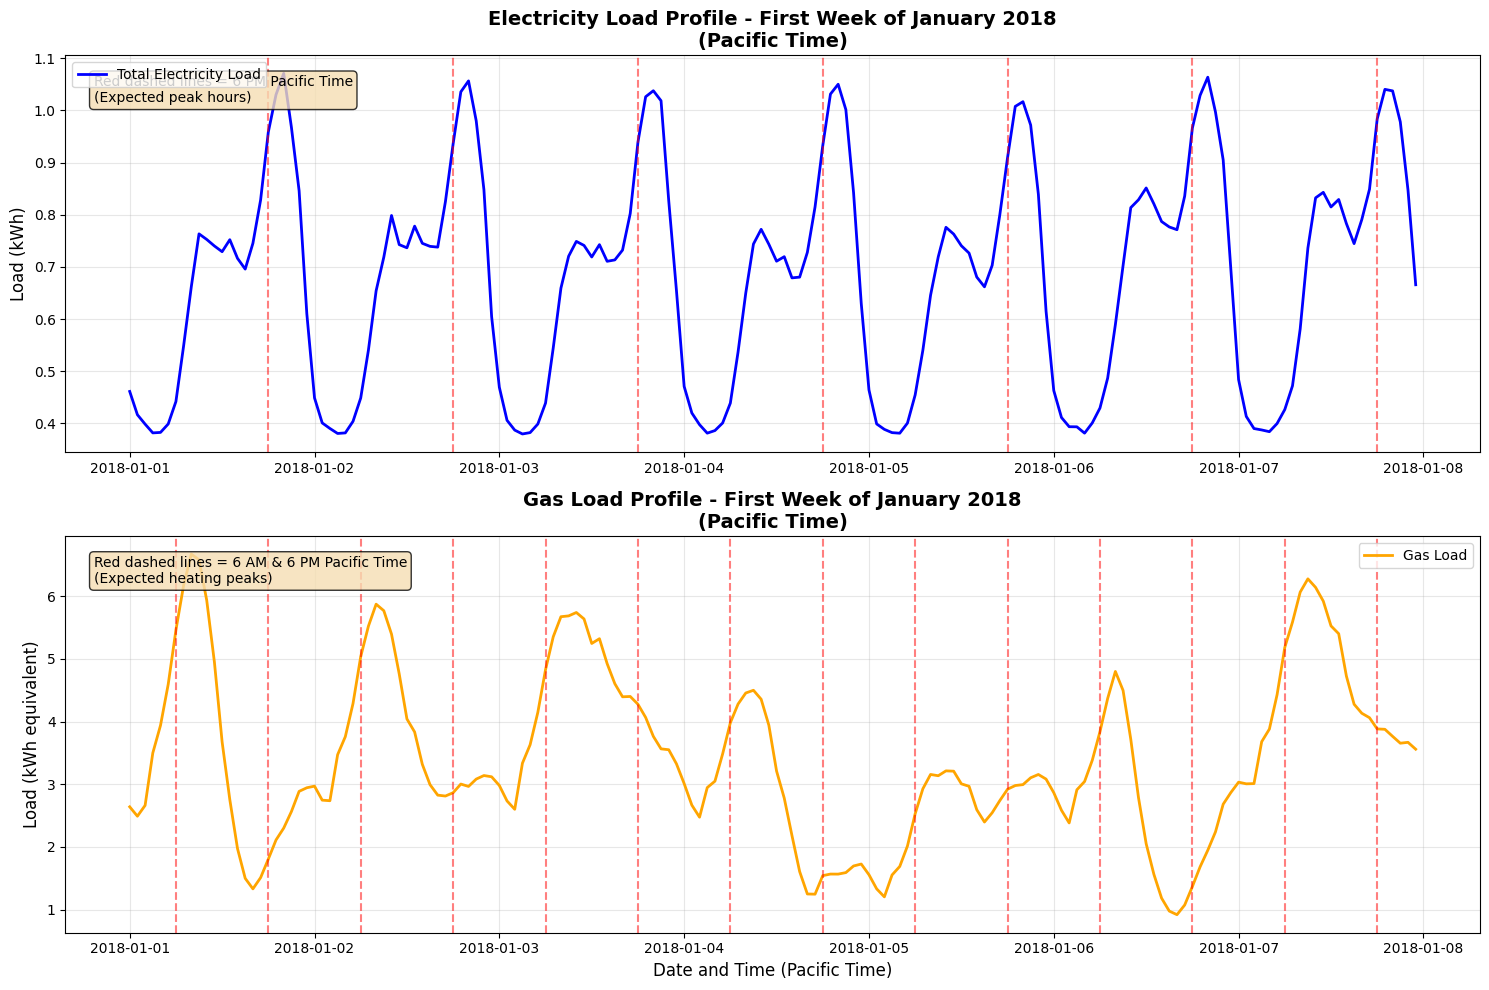

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Electricity load - January
if elec_jan is not None:
    axes[0].plot(elec_jan['timestamp'], elec_jan.get('total_load', elec_jan.iloc[:, 1]), 
                 color='blue', linewidth=2, label='Total Electricity Load')
    axes[0].set_title('Electricity Load Profile - First Week of January 2018\n(Pacific Time)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Load (kWh)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Add vertical lines for 6 PM each day to verify timezone
    for day in range(7):
        evening_time = pd.Timestamp(f'2018-01-{day+1:02d} 18:00:00')
        if evening_time >= elec_jan['timestamp'].min() and evening_time <= elec_jan['timestamp'].max():
            axes[0].axvline(x=evening_time, color='red', linestyle='--', alpha=0.5)
    
    # Add text annotation
    axes[0].text(0.02, 0.95, 'Red dashed lines = 6 PM Pacific Time\n(Expected peak hours)', 
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
else:
    axes[0].text(0.5, 0.5, 'Electricity data not available', 
                ha='center', va='center', transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title('Electricity Load Profile - January (Data Not Found)')

# Gas load - January
if gas_jan is not None:
    gas_load_col = 'load.gas.building_avg.kwh' if 'load.gas.building_avg.kwh' in gas_jan.columns else gas_jan.columns[1]
    axes[1].plot(gas_jan['timestamp'], gas_jan[gas_load_col], 
                 color='orange', linewidth=2, label='Gas Load')
    axes[1].set_title('Gas Load Profile - First Week of January 2018\n(Pacific Time)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Load (kWh equivalent)', fontsize=12)
    axes[1].set_xlabel('Date and Time (Pacific Time)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Add vertical lines for 6 AM and 6 PM each day
    for day in range(7):
        morning_time = pd.Timestamp(f'2018-01-{day+1:02d} 06:00:00')
        evening_time = pd.Timestamp(f'2018-01-{day+1:02d} 18:00:00')
        for time_mark in [morning_time, evening_time]:
            if time_mark >= gas_jan['timestamp'].min() and time_mark <= gas_jan['timestamp'].max():
                axes[1].axvline(x=time_mark, color='red', linestyle='--', alpha=0.5)
    
    axes[1].text(0.02, 0.95, 'Red dashed lines = 6 AM & 6 PM Pacific Time\n(Expected heating peaks)', 
                transform=axes[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
else:
    axes[1].text(0.5, 0.5, 'Gas data not available', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Gas Load Profile - January (Data Not Found)')
    axes[1].set_xlabel('Date and Time')

plt.tight_layout()
plt.show()

## Visualization: First Week of July

Summer load patterns - we expect:
- Higher electricity usage for cooling
- Lower gas usage (minimal heating)
- Peak electricity usage in afternoon/evening (Pacific Time)

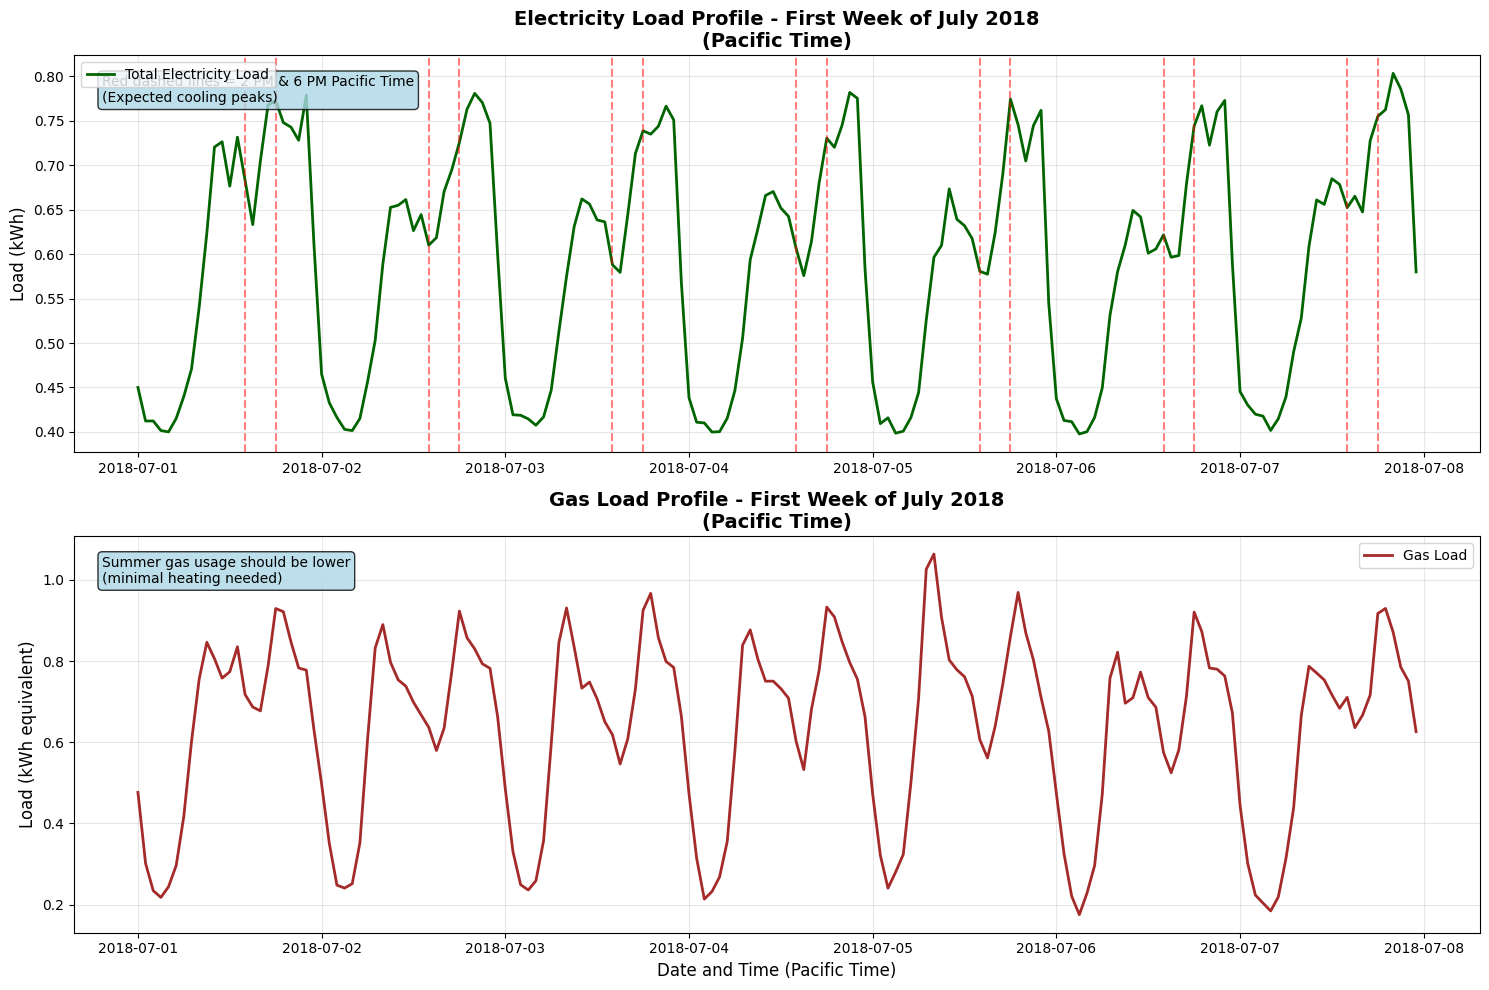

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Electricity load - July
if elec_jul is not None:
    axes[0].plot(elec_jul['timestamp'], elec_jul.get('total_load', elec_jul.iloc[:, 1]), 
                 color='darkgreen', linewidth=2, label='Total Electricity Load')
    axes[0].set_title('Electricity Load Profile - First Week of July 2018\n(Pacific Time)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Load (kWh)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Add vertical lines for 2 PM and 6 PM each day (peak cooling hours)
    for day in range(7):
        afternoon_time = pd.Timestamp(f'2018-07-{day+1:02d} 14:00:00')
        evening_time = pd.Timestamp(f'2018-07-{day+1:02d} 18:00:00')
        for time_mark in [afternoon_time, evening_time]:
            if time_mark >= elec_jul['timestamp'].min() and time_mark <= elec_jul['timestamp'].max():
                axes[0].axvline(x=time_mark, color='red', linestyle='--', alpha=0.5)
    
    axes[0].text(0.02, 0.95, 'Red dashed lines = 2 PM & 6 PM Pacific Time\n(Expected cooling peaks)', 
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
else:
    axes[0].text(0.5, 0.5, 'Electricity data not available', 
                ha='center', va='center', transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title('Electricity Load Profile - July (Data Not Found)')

# Gas load - July
if gas_jul is not None:
    gas_load_col = 'load.gas.building_avg.kwh' if 'load.gas.building_avg.kwh' in gas_jul.columns else gas_jul.columns[1]
    axes[1].plot(gas_jul['timestamp'], gas_jul[gas_load_col], 
                 color='brown', linewidth=2, label='Gas Load')
    axes[1].set_title('Gas Load Profile - First Week of July 2018\n(Pacific Time)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Load (kWh equivalent)', fontsize=12)
    axes[1].set_xlabel('Date and Time (Pacific Time)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    axes[1].text(0.02, 0.95, 'Summer gas usage should be lower\n(minimal heating needed)', 
                transform=axes[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
else:
    axes[1].text(0.5, 0.5, 'Gas data not available', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Gas Load Profile - July (Data Not Found)')
    axes[1].set_xlabel('Date and Time')

plt.tight_layout()
plt.show()

## Hourly Pattern Analysis

Let's create hourly heatmaps to better visualize the daily patterns and verify timezone correctness.

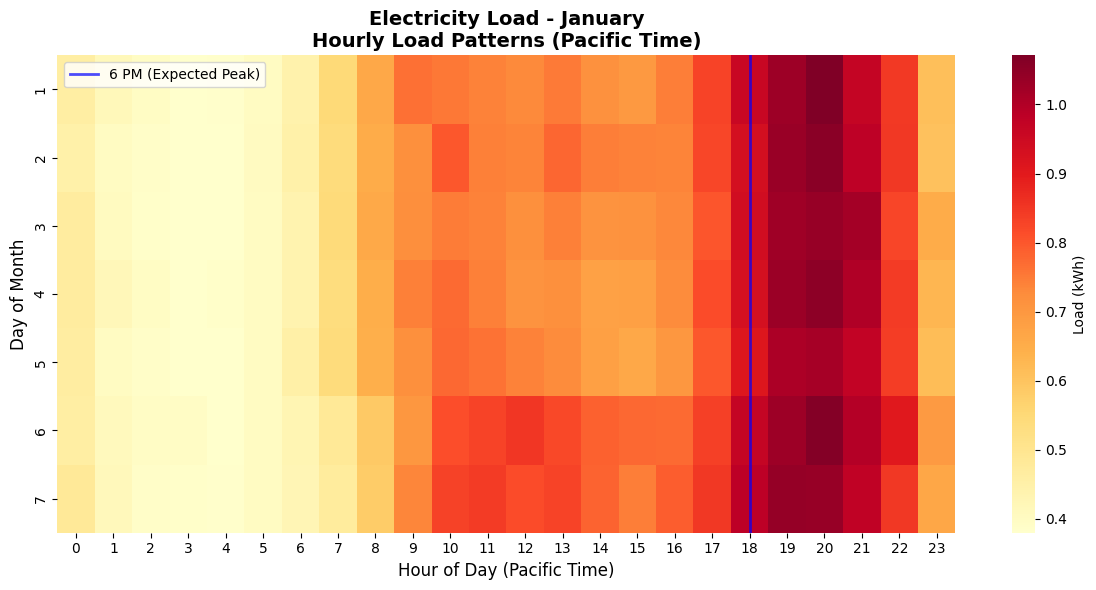

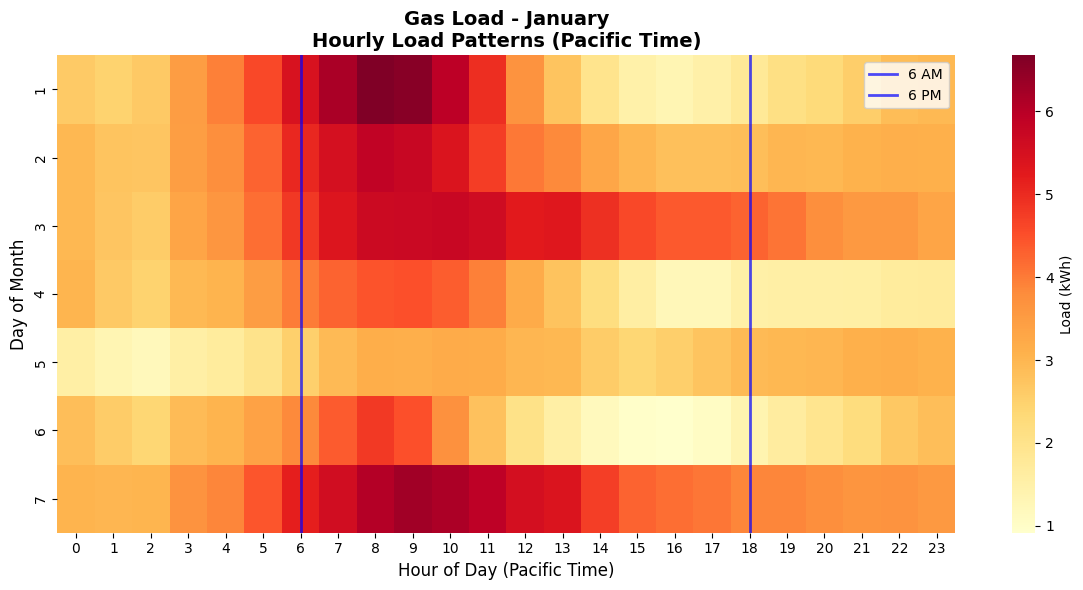

In [42]:
def create_hourly_heatmap(df, title, load_column):
    """Create hourly heatmap for a week of data"""
    if df is None:
        return
    
    # Prepare data
    df_copy = df.copy()
    df_copy['hour'] = df_copy['timestamp'].dt.hour
    df_copy['day'] = df_copy['timestamp'].dt.day
    df_copy['day_name'] = df_copy['timestamp'].dt.day_name()
    
    # Create pivot table
    if load_column in df_copy.columns:
        pivot_data = df_copy.pivot_table(values=load_column, index='day', columns='hour', aggfunc='mean')
        
        # Create heatmap
        plt.figure(figsize=(12, 6))
        sns.heatmap(pivot_data, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Load (kWh)'})
        plt.title(f'{title}\nHourly Load Patterns (Pacific Time)', fontsize=14, fontweight='bold')
        plt.xlabel('Hour of Day (Pacific Time)', fontsize=12)
        plt.ylabel('Day of Month', fontsize=12)
        
        # Add vertical lines for expected peak hours
        if 'electricity' in title.lower():
            plt.axvline(x=18.5, color='blue', linewidth=2, alpha=0.7, label='6 PM (Expected Peak)')
        else:
            plt.axvline(x=6.5, color='blue', linewidth=2, alpha=0.7, label='6 AM')
            plt.axvline(x=18.5, color='blue', linewidth=2, alpha=0.7, label='6 PM')
        
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{load_column}' not found in data. Available columns: {list(df_copy.columns)}")

# Create heatmaps for January data
if elec_jan is not None:
    elec_load_col = 'total_load' if 'total_load' in elec_jan.columns else elec_jan.columns[1]
    create_hourly_heatmap(elec_jan, 'Electricity Load - January', elec_load_col)

if gas_jan is not None:
    gas_load_col = 'load.gas.building_avg.kwh' if 'load.gas.building_avg.kwh' in gas_jan.columns else gas_jan.columns[1]
    create_hourly_heatmap(gas_jan, 'Gas Load - January', gas_load_col)

## Summary and Verification Results

Based on the visualizations above, let's summarize the timezone verification results:

In [43]:
print("=" * 60)
print("TIMEZONE VERIFICATION SUMMARY")
print("=" * 60)

print("\n✅ VERIFICATION CHECKLIST:")
print("\n1. Data Loading:")
print(f"   - Electricity data loaded: {'✅' if elec_df is not None else '❌'}")
print(f"   - Gas data loaded: {'✅' if gas_df is not None else '❌'}")

if elec_df is not None or gas_df is not None:
    print("\n2. Timezone Indicators to Look For:")
    print("   - Peak electricity usage around 6-8 PM Pacific Time ⏰")
    print("   - Gas heating peaks around 6-8 AM and 6-8 PM Pacific Time ⏰")
    print("   - Higher gas usage in January (winter heating) vs July 🔥")
    print("   - Higher electricity usage in July (summer cooling) vs January ❄️")
    
    print("\n3. Expected Patterns for Pacific Time:")
    print("   - Morning electricity rise: 6-8 AM")
    print("   - Evening electricity peak: 6-8 PM")
    print("   - Gas heating peaks: 6-8 AM and 6-8 PM (winter)")
    print("   - Lower gas usage in summer months")
    
    print("\n4. Signs of Incorrect Timezone (if peaks are shifted):")
    print("   - ⚠️  Peaks at 3-5 AM or 3-5 PM = Still in Eastern Time")
    print("   - ⚠️  Peaks at 9-11 AM or 9-11 PM = Shifted to UTC")
    print("   - ✅ Peaks at 6-8 AM or 6-8 PM = Correct Pacific Time")

print("\n" + "=" * 60)
print("INSTRUCTIONS:")
print("1. Examine the line plots above for daily patterns")
print("2. Check if peaks align with red dashed lines (expected times)")
print("3. Compare January vs July seasonal differences")
print("4. Review the hourly heatmaps for pattern consistency")
print("=" * 60)

TIMEZONE VERIFICATION SUMMARY

✅ VERIFICATION CHECKLIST:

1. Data Loading:
   - Electricity data loaded: ✅
   - Gas data loaded: ✅

2. Timezone Indicators to Look For:
   - Peak electricity usage around 6-8 PM Pacific Time ⏰
   - Gas heating peaks around 6-8 AM and 6-8 PM Pacific Time ⏰
   - Higher gas usage in January (winter heating) vs July 🔥
   - Higher electricity usage in July (summer cooling) vs January ❄️

3. Expected Patterns for Pacific Time:
   - Morning electricity rise: 6-8 AM
   - Evening electricity peak: 6-8 PM
   - Gas heating peaks: 6-8 AM and 6-8 PM (winter)
   - Lower gas usage in summer months

4. Signs of Incorrect Timezone (if peaks are shifted):
   - ⚠️  Peaks at 3-5 AM or 3-5 PM = Still in Eastern Time
   - ⚠️  Peaks at 9-11 AM or 9-11 PM = Shifted to UTC
   - ✅ Peaks at 6-8 AM or 6-8 PM = Correct Pacific Time

INSTRUCTIONS:
1. Examine the line plots above for daily patterns
2. Check if peaks align with red dashed lines (expected times)
3. Compare January vs Ju

## Additional Analysis: Compare Original vs Converted Timestamps

If you want to see the actual timezone conversion in action, run the cell below to show how timestamps would look before and after conversion:

In [44]:
# Demonstrate timezone conversion
print("TIMEZONE CONVERSION DEMONSTRATION:")
print("=" * 50)

# Create sample Eastern Time timestamps
sample_times_et = pd.date_range(start='2018-01-01 00:00:00', periods=24, freq='H')

# Convert to Pacific Time (same as our load profile conversion)
sample_times_pt = sample_times_et.tz_localize('US/Eastern', ambiguous=False, nonexistent='shift_forward').tz_convert('US/Pacific').tz_localize(None)

# Show comparison
comparison_df = pd.DataFrame({
    'Original_Eastern_Time': sample_times_et,
    'Converted_Pacific_Time': sample_times_pt,
    'Hour_Difference': (sample_times_pt.hour - sample_times_et.hour) % 24
})

print("Sample of timezone conversion (first 12 hours):")
print(comparison_df.head(12).to_string(index=False))

print(f"\nTime difference: {(sample_times_pt[0] - sample_times_et[0]).total_seconds() / 3600:.0f} hours")
print("✅ Eastern Time 6:00 PM becomes Pacific Time 3:00 PM (3-hour difference)")
print("✅ This means evening peaks now occur at the correct Pacific Time hours")

TIMEZONE CONVERSION DEMONSTRATION:
Sample of timezone conversion (first 12 hours):
Original_Eastern_Time Converted_Pacific_Time  Hour_Difference
  2018-01-01 00:00:00    2017-12-31 21:00:00               21
  2018-01-01 01:00:00    2017-12-31 22:00:00               21
  2018-01-01 02:00:00    2017-12-31 23:00:00               21
  2018-01-01 03:00:00    2018-01-01 00:00:00               21
  2018-01-01 04:00:00    2018-01-01 01:00:00               21
  2018-01-01 05:00:00    2018-01-01 02:00:00               21
  2018-01-01 06:00:00    2018-01-01 03:00:00               21
  2018-01-01 07:00:00    2018-01-01 04:00:00               21
  2018-01-01 08:00:00    2018-01-01 05:00:00               21
  2018-01-01 09:00:00    2018-01-01 06:00:00               21
  2018-01-01 10:00:00    2018-01-01 07:00:00               21
  2018-01-01 11:00:00    2018-01-01 08:00:00               21

Time difference: -3 hours
✅ Eastern Time 6:00 PM becomes Pacific Time 3:00 PM (3-hour difference)
✅ This means